# Statistical Analysis
## Public Compliance Data Analysis - MBA Thesis

**Objective:** Perform rigorous statistical analysis:
- Correlation analysis
- Hypothesis testing
- Multiple linear regression
- Model diagnostics and validation

In [58]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro, normaltest, jarque_bera

from src.analysis.data_loader import GoldDataLoader

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)


In [59]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


## 1. Load Data

In [60]:
loader = GoldDataLoader(
    bucket_name="enok-mba-thesis-datalake",
    aws_profile="mba-thesis"
)

df = loader.load_dataset('analysis_compliance')
print(f"Loaded {len(df)} observations (states)")
df.head()

2026-02-09 02:59:38,085 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2026-02-09 02:59:38,247 - INFO - 📥 Loading analysis_compliance from S3: gold/analysis_compliance/data.parquet
2026-02-09 02:59:39,070 - INFO - ✅ Loaded 27 records, 21 columns


Loaded 27 observations (states)


,state_code,state_name,region_code,region_name,n_municipalities,population,avg_literacy_rate,avg_income,n_sanctions,n_sanctions_ceis,n_sanctions_cnep,n_sanctions_ceaf,n_sanctions_cepim,sanctions_per_100k,log_population,log_income,is_norte,is_nordeste,is_sudeste,is_sul,is_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.2900,1211.9600,0,0,0,0,0,0.0000,14.2737,7.1000,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.4100,778.4900,1,1,0,0,0,0.1205,13.6292,6.6574,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.9600,625.4400,0,0,0,0,0,0.0000,15.1871,6.4385,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.7000,724.2000,0,0,0,0,0,0.0000,13.3641,6.5851,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.8400,764.4600,1,1,0,0,0,0.0123,15.9099,6.6392,1,0,0,0,0


## 2. Correlation Analysis

### 2.1 Pearson Correlation Matrix

In [ ]:
key_vars = ['sanctions_per_100k', 'avg_literacy_rate', 'avg_income', 
            'log_population', 'log_income', 'n_municipalities']

corr_matrix = df[key_vars].corr(method='pearson')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Pearson Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelations with Sanctions per 100k:")
print("=" * 60)
sanctions_corr = corr_matrix['sanctions_per_100k'].sort_values(ascending=False)
print(sanctions_corr)

### 2.2 Statistical Significance Testing

In [43]:
from scipy.stats import pearsonr

def correlation_test(x, y, var_names):
    """Compute Pearson correlation with p-value."""
    clean_data = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(clean_data) < 3:
        return None, None
    r, p = pearsonr(clean_data['x'], clean_data['y'])
    return r, p

results = []
target = df['sanctions_per_100k']

for var in ['avg_literacy_rate', 'avg_income', 'log_income', 'log_population', 'n_municipalities']:
    r, p = correlation_test(target, df[var], (var, 'sanctions_per_100k'))
    if r is not None:
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        results.append({
            'Variable': var,
            'Correlation (r)': f"{r:.4f}",
            'P-value': f"{p:.4f}",
            'Significance': sig
        })

corr_results = pd.DataFrame(results)
print("\nCorrelation Tests with Sanctions per 100k")
print("=" * 80)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("=" * 80)
display(corr_results)


Correlation Tests with Sanctions per 100k
Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


,Variable,Correlation (r),P-value,Significance
0,avg_literacy_rate,-0.0179,0.9295,ns
1,avg_income,-0.0048,0.9809,ns
2,log_income,0.0099,0.9611,ns
3,log_population,-0.2305,0.2473,ns
4,n_municipalities,-0.1439,0.4738,ns


### 2.3 Scatter Plots with Regression Lines

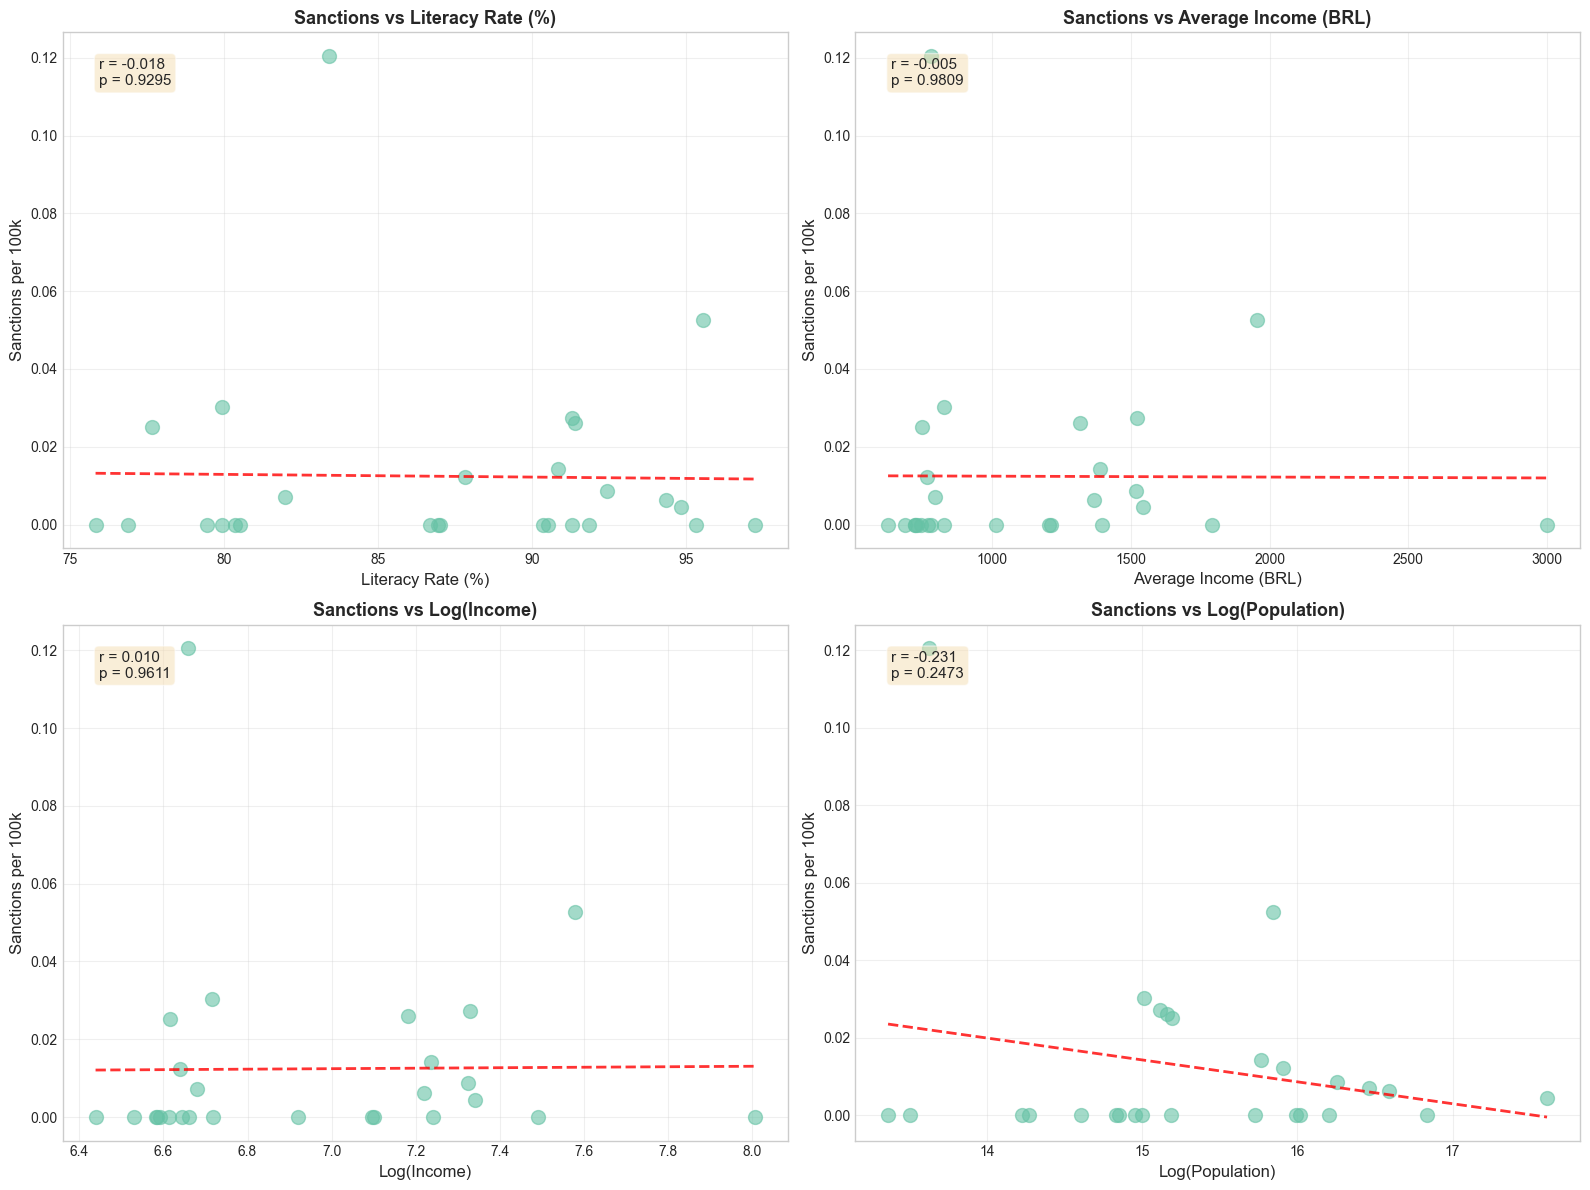

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

vars_to_plot = [
    ('avg_literacy_rate', 'Literacy Rate (%)', axes[0, 0]),
    ('avg_income', 'Average Income (BRL)', axes[0, 1]),
    ('log_income', 'Log(Income)', axes[1, 0]),
    ('log_population', 'Log(Population)', axes[1, 1])
]

for var, label, ax in vars_to_plot:
    ax.scatter(df[var], df['sanctions_per_100k'], alpha=0.6, s=100)
    
    z = np.polyfit(df[var].dropna(), df['sanctions_per_100k'][df[var].notna()], 1)
    p = np.poly1d(z)
    ax.plot(df[var].sort_values(), p(df[var].sort_values()), "r--", alpha=0.8, linewidth=2)
    
    r, pval = correlation_test(df[var], df['sanctions_per_100k'], (var, 'sanctions'))
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.4f}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Sanctions per 100k', fontsize=12)
    ax.set_title(f'Sanctions vs {label}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Hypothesis Testing

### 3.1 Regional Differences (ANOVA)

In [45]:
from scipy.stats import f_oneway

regions = df['region_name'].unique()
groups = [df[df['region_name'] == region]['sanctions_per_100k'].dropna() for region in regions]

f_stat, p_value = f_oneway(*groups)

print("One-Way ANOVA: Regional Differences in Sanctions per 100k")
print("=" * 70)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nResult: {'Significant' if p_value < 0.05 else 'Not significant'} regional differences")
print("\nRegional Means:")
print(df.groupby('region_name')['sanctions_per_100k'].agg(['mean', 'std', 'count']).round(2))

One-Way ANOVA: Regional Differences in Sanctions per 100k
F-statistic: 0.2850
P-value: 0.8846

Result: Not significant regional differences

Regional Means:
               mean    std  count
region_name                      
Centro-Oeste 0.0100 0.0100      4
Nordeste     0.0100 0.0100      9
Norte        0.0200 0.0500      7
Sudeste      0.0100 0.0100      4
Sul          0.0200 0.0300      3


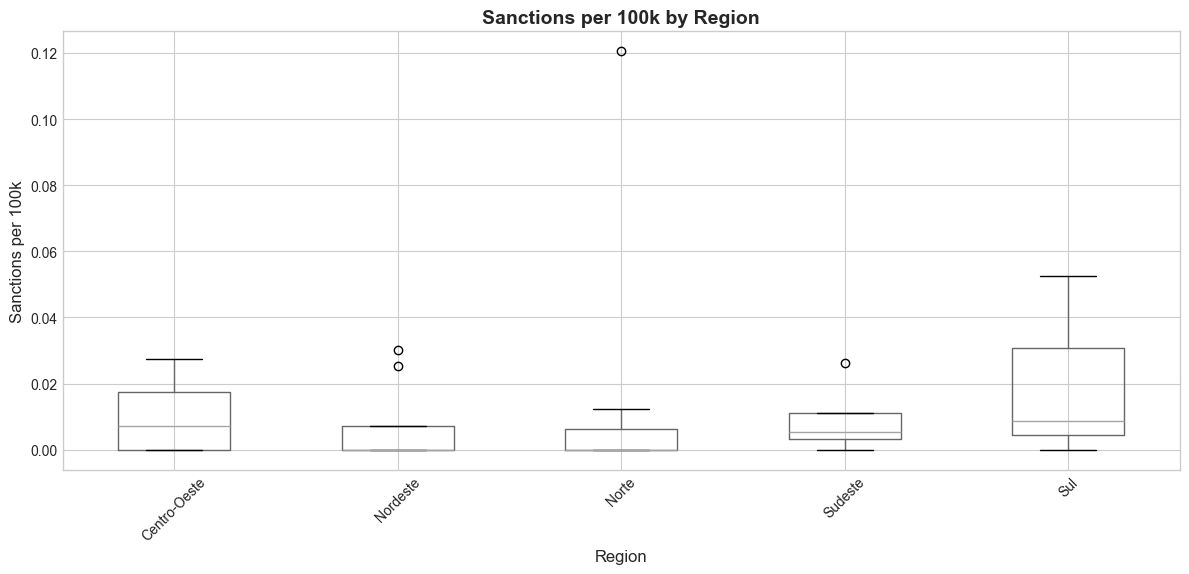

In [46]:
plt.figure(figsize=(12, 6))
df.boxplot(column='sanctions_per_100k', by='region_name', ax=plt.gca())
plt.title('Sanctions per 100k by Region', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sanctions per 100k', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Post-hoc Tests (Tukey HSD)

Tukey HSD Post-hoc Test
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1     group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------------
Centro-Oeste Nordeste  -0.0034 0.9995 -0.0512 0.0444  False
Centro-Oeste    Norte   0.0086 0.9853 -0.0413 0.0585  False
Centro-Oeste  Sudeste  -0.0012    1.0 -0.0574 0.0551  False
Centro-Oeste      Sul   0.0101 0.9874 -0.0507 0.0708  False
    Nordeste    Norte    0.012 0.8979 -0.0281 0.0521  False
    Nordeste  Sudeste   0.0022 0.9999 -0.0456 0.0501  False
    Nordeste      Sul   0.0135  0.941 -0.0396 0.0665  False
       Norte  Sudeste  -0.0098 0.9765 -0.0597 0.0401  False
       Norte      Sul   0.0015    1.0 -0.0535 0.0564  False
     Sudeste      Sul   0.0112  0.981 -0.0495  0.072  False
-----------------------------------------------------------


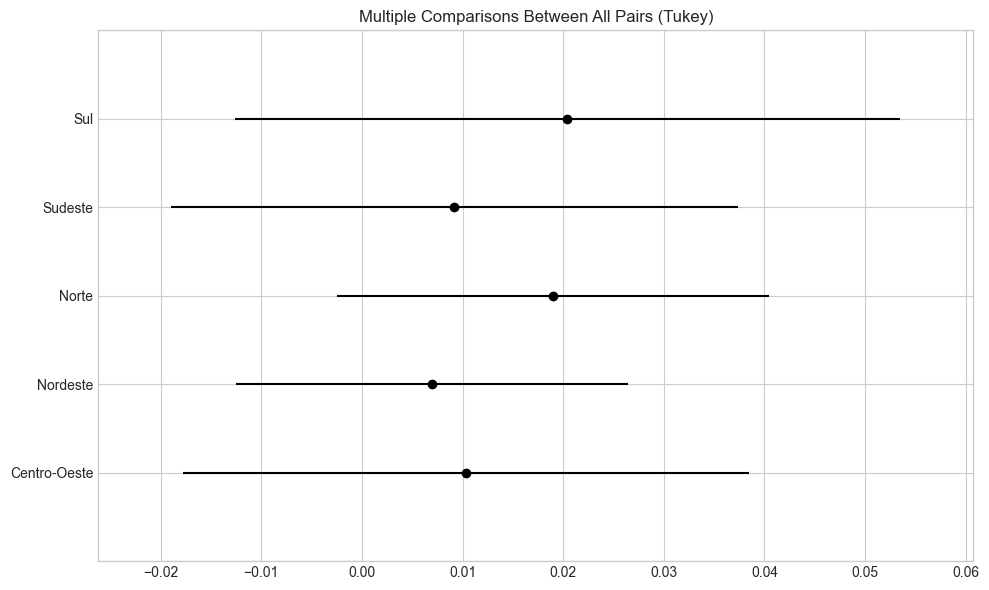

In [47]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['sanctions_per_100k'], 
                          groups=df['region_name'], 
                          alpha=0.05)

print("Tukey HSD Post-hoc Test")
print("=" * 80)
print(tukey)

tukey.plot_simultaneous()
plt.tight_layout()
plt.show()

## 4. Multiple Linear Regression

### 4.1 Model Specification

In [48]:
y = df['sanctions_per_100k']

X_vars = ['log_income', 'avg_literacy_rate', 'log_population', 
          'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

# Convert to float to avoid dtype issues with statsmodels
X = df[X_vars].copy().astype(float)
X = sm.add_constant(X)

print("Model Specification:")
print("=" * 70)
print(f"Dependent Variable: sanctions_per_100k")
print(f"Independent Variables: {X_vars}")
print(f"\nSample size: {len(X)}")
print(f"Number of predictors: {len(X_vars)}")

Model Specification:
Dependent Variable: sanctions_per_100k
Independent Variables: ['log_income', 'avg_literacy_rate', 'log_population', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

Sample size: 27
Number of predictors: 7


### 4.2 OLS Regression

In [49]:
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     sanctions_per_100k   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.036
Date:                Mon, 09 Feb 2026   Prob (F-statistic):              0.439
Time:                        02:52:42   Log-Likelihood:                 65.835
No. Observations:                  27   AIC:                            -115.7
Df Residuals:                      19   BIC:                            -105.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3793      0.25

### 4.3 Coefficient Interpretation

In [50]:
coef_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'Std Error': model.bse.values,
    't-statistic': model.tvalues.values,
    'P-value': model.pvalues.values,
    'CI Lower': model.conf_int()[0].values,
    'CI Upper': model.conf_int()[1].values
})

coef_df['Significant'] = coef_df['P-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

print("\nRegression Coefficients")
print("=" * 100)
display(coef_df.round(4))


Regression Coefficients


,Variable,Coefficient,Std Error,t-statistic,P-value,CI Lower,CI Upper,Significant
0,const,0.3793,0.2557,1.4833,0.1544,-0.1559,0.9145,ns
1,log_income,0.0444,0.0402,1.1027,0.2839,-0.0399,0.1286,ns
2,avg_literacy_rate,-0.0068,0.0033,-2.0519,0.0542,-0.0138,0.0001,ns
3,log_population,-0.0035,0.0078,-0.4481,0.6591,-0.0197,0.0128,ns
4,is_norte,-0.0110,0.0277,-0.3959,0.6966,-0.0690,0.0471,ns
5,is_nordeste,-0.0727,0.0352,-2.0623,0.0531,-0.1465,0.0011,ns
6,is_sul,0.0100,0.0207,0.4816,0.6356,-0.0333,0.0532,ns
7,is_centro_oeste,-0.0140,0.0214,-0.6529,0.5216,-0.0589,0.0309,ns


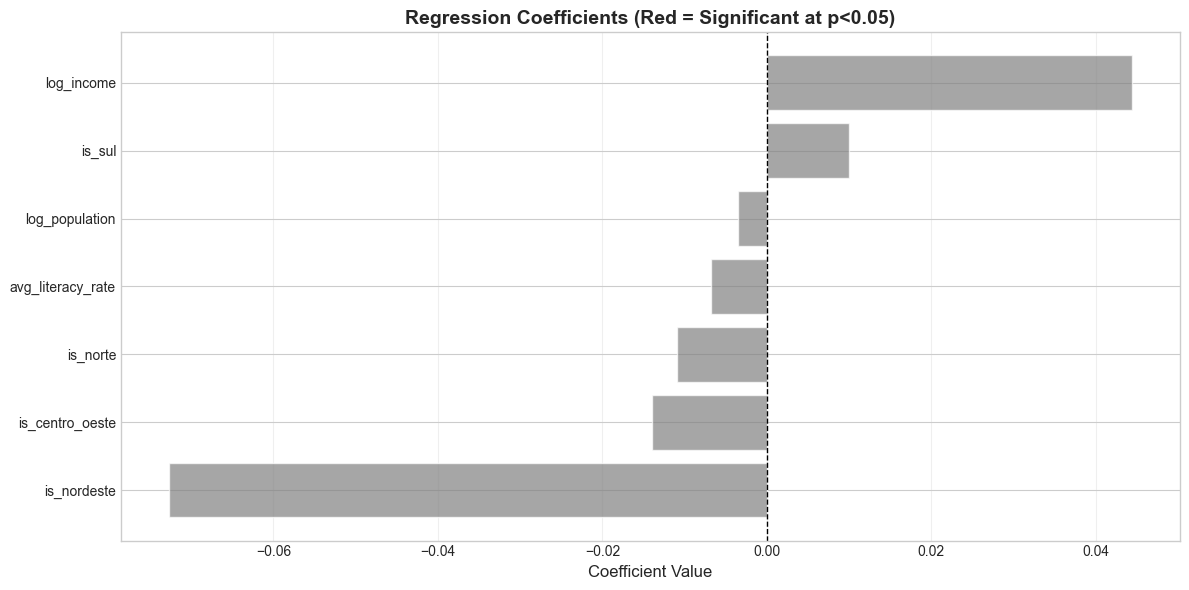

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))

coef_plot = coef_df[coef_df['Variable'] != 'const'].copy()
coef_plot = coef_plot.sort_values('Coefficient')

colors = ['red' if p < 0.05 else 'gray' for p in coef_plot['P-value']]

ax.barh(coef_plot['Variable'], coef_plot['Coefficient'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Regression Coefficients (Red = Significant at p<0.05)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 5. Model Diagnostics

### 5.1 Residual Analysis

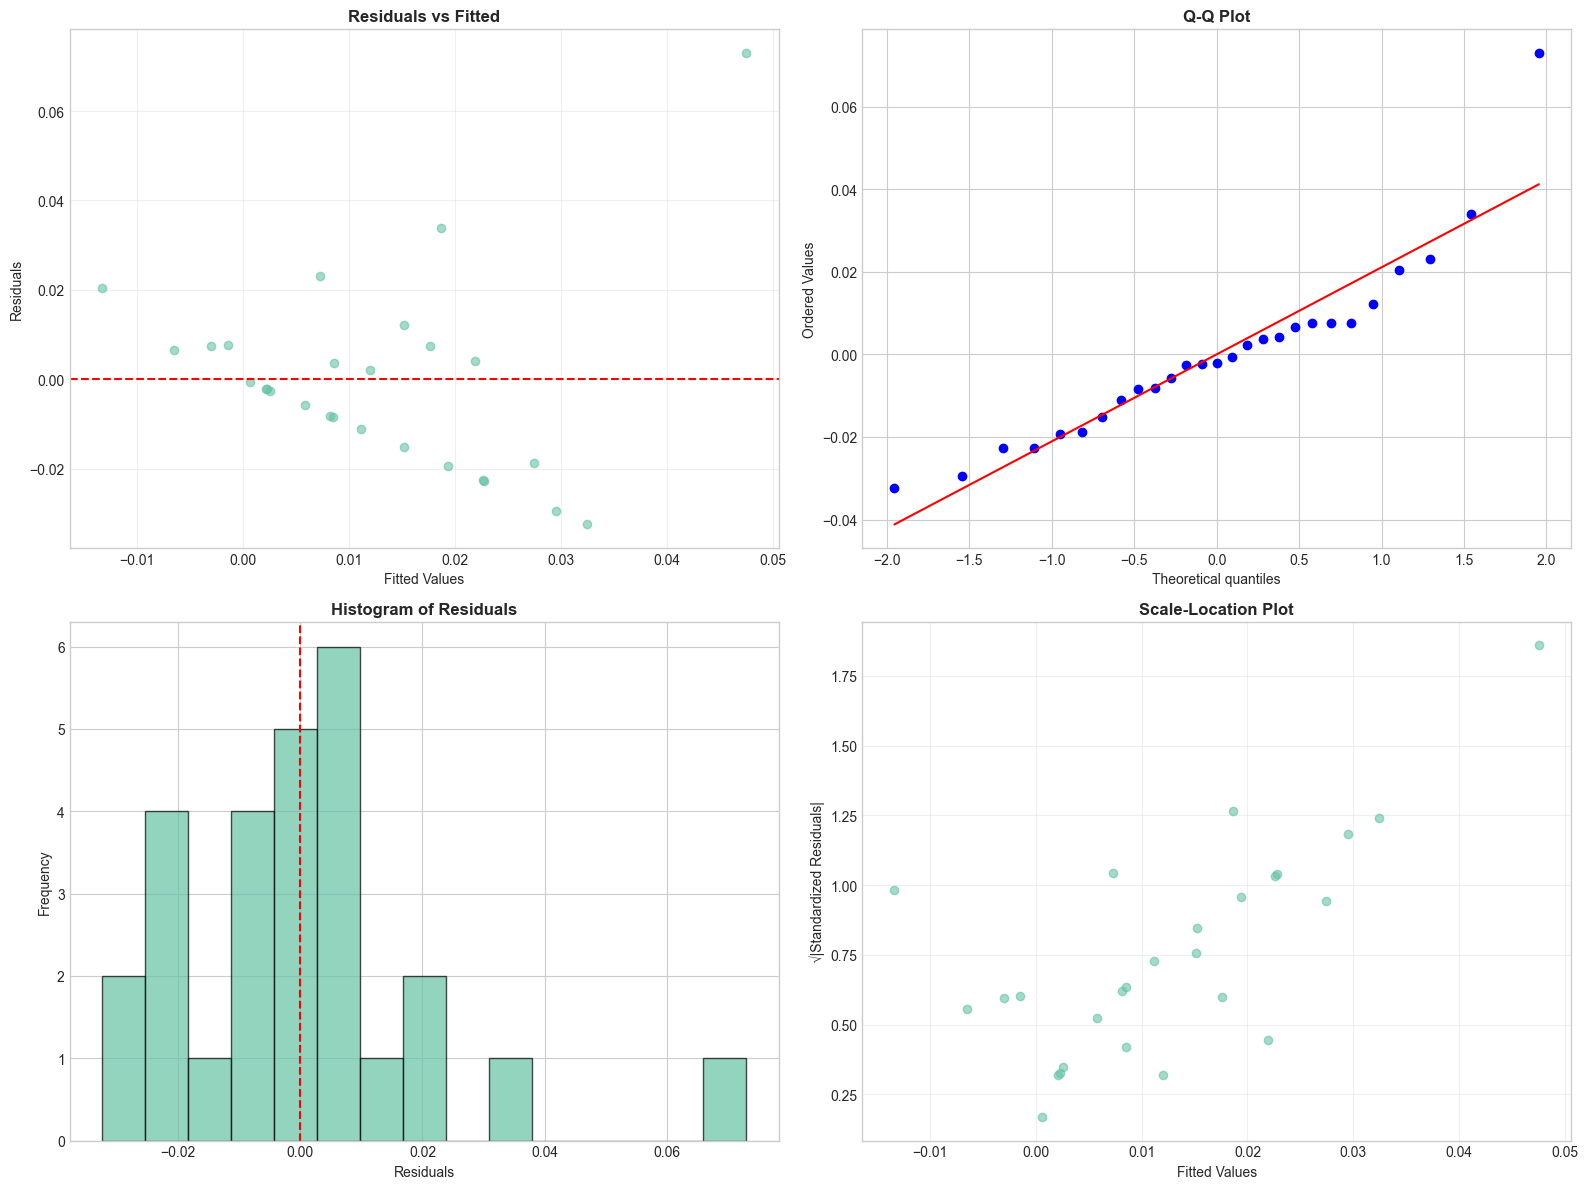

In [52]:
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(fitted, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot', fontweight='bold')

axes[1, 0].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Histogram of Residuals', fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--')

standardized_resid = residuals / np.std(residuals)
axes[1, 1].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Standardized Residuals|')
axes[1, 1].set_title('Scale-Location Plot', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Normality Tests

In [53]:
shapiro_stat, shapiro_p = shapiro(residuals)
jb_stat, jb_p = jarque_bera(residuals)

print("Normality Tests for Residuals")
print("=" * 70)
print(f"Shapiro-Wilk Test:")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
print(f"  Result: {'Reject normality' if shapiro_p < 0.05 else 'Cannot reject normality'}\n")

print(f"Jarque-Bera Test:")
print(f"  Statistic: {jb_stat:.4f}")
print(f"  P-value: {jb_p:.4f}")
print(f"  Result: {'Reject normality' if jb_p < 0.05 else 'Cannot reject normality'}")

Normality Tests for Residuals
Shapiro-Wilk Test:
  Statistic: 0.8986
  P-value: 0.0124
  Result: Reject normality

Jarque-Bera Test:
  Statistic: 19.4349
  P-value: 0.0001
  Result: Reject normality


### 5.3 Heteroskedasticity Tests

In [54]:
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)

print("Heteroskedasticity Tests")
print("=" * 70)
print(f"Breusch-Pagan Test:")
print(f"  Statistic: {bp_stat:.4f}")
print(f"  P-value: {bp_p:.4f}")
print(f"  Result: {'Heteroskedasticity detected' if bp_p < 0.05 else 'Homoskedasticity (constant variance)'}")

Heteroskedasticity Tests
Breusch-Pagan Test:
  Statistic: 12.8577
  P-value: 0.0757
  Result: Homoskedasticity (constant variance)


### 5.4 Multicollinearity (VIF)

In [55]:
X_no_const = X.drop('const', axis=1)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_no_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_no_const.values, i) 
                   for i in range(X_no_const.shape[1])]

vif_data['Multicollinearity'] = vif_data['VIF'].apply(
    lambda x: 'High (>10)' if x > 10 else 'Moderate (5-10)' if x > 5 else 'Low (<5)'
)

print("Variance Inflation Factor (VIF) Analysis")
print("=" * 70)
print("Rule of thumb: VIF > 10 indicates high multicollinearity\n")
display(vif_data.sort_values('VIF', ascending=False))

Variance Inflation Factor (VIF) Analysis
Rule of thumb: VIF > 10 indicates high multicollinearity



,Variable,VIF,Multicollinearity
1,avg_literacy_rate,3412.2430,High (>10)
0,log_income,2672.5161,High (>10)
2,log_population,485.9812,High (>10)
4,is_nordeste,8.8052,Moderate (5-10)
3,is_norte,3.6843,Low (<5)
6,is_centro_oeste,2.8933,Low (<5)
5,is_sul,1.9589,Low (<5)


### 5.5 Influential Observations

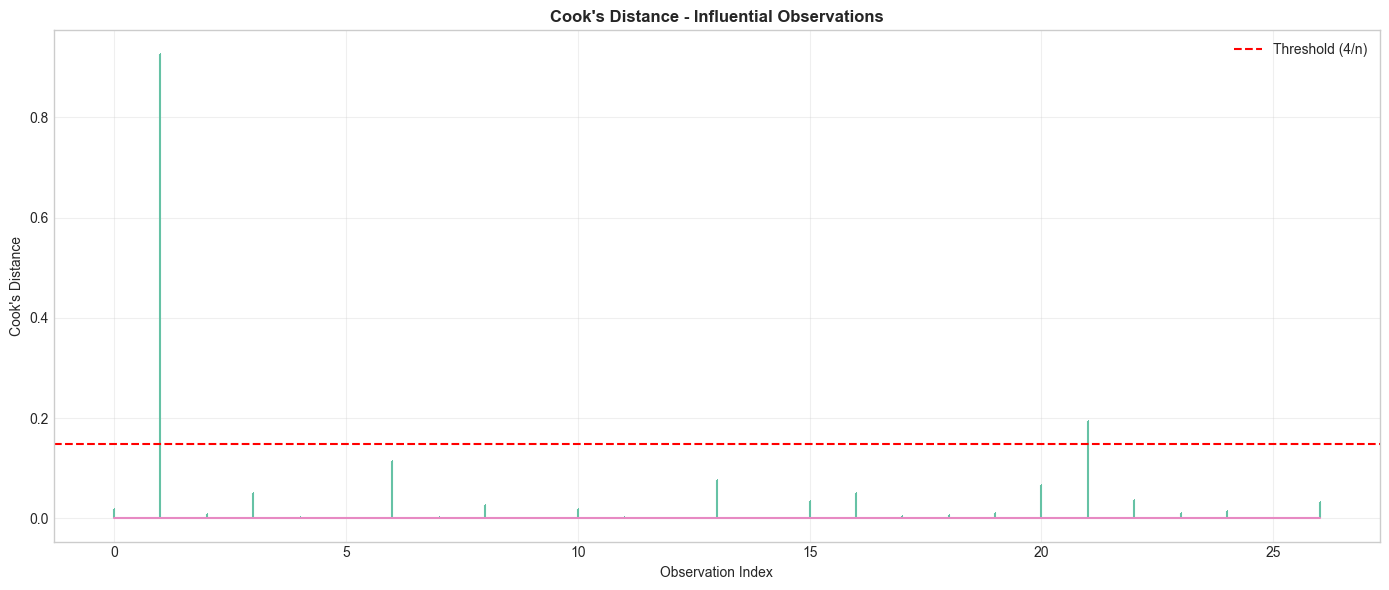


Influential observations (Cook's D > 0.1481):
        state_name  sanctions_per_100k
1             Acre              0.1205
21  Santa Catarina              0.0526


In [56]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
ax.axhline(y=4/len(X), color='r', linestyle='--', label='Threshold (4/n)')
ax.set_xlabel('Observation Index')
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance - Influential Observations", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

threshold = 4 / len(X)
influential = df[cooks_d > threshold][['state_name', 'sanctions_per_100k']]
if len(influential) > 0:
    print(f"\nInfluential observations (Cook's D > {threshold:.4f}):")
    print(influential)
else:
    print("\nNo highly influential observations detected.")

## 6. Model Comparison

In [57]:
X_simple = sm.add_constant(df[['log_income', 'avg_literacy_rate']])
model_simple = sm.OLS(y, X_simple).fit()

X_full = X.copy()
model_full = model

comparison = pd.DataFrame({
    'Model': ['Simple (2 vars)', 'Full (7 vars + regions)'],
    'R-squared': [model_simple.rsquared, model_full.rsquared],
    'Adj. R-squared': [model_simple.rsquared_adj, model_full.rsquared_adj],
    'AIC': [model_simple.aic, model_full.aic],
    'BIC': [model_simple.bic, model_full.bic],
    'F-statistic': [model_simple.fvalue, model_full.fvalue],
    'Prob (F)': [model_simple.f_pvalue, model_full.f_pvalue]
})

print("Model Comparison")
print("=" * 80)
display(comparison.round(4))

print("\nNote: Lower AIC/BIC indicates better model fit")

Model Comparison


,Model,R-squared,Adj. R-squared,AIC,BIC,F-statistic,Prob (F)
0,Simple (2 vars),0.0025,-0.0806,-117.0099,-113.1224,0.0299,0.9706
1,Full (7 vars + regions),0.2762,0.0095,-115.6699,-105.3032,1.0357,0.4394



Note: Lower AIC/BIC indicates better model fit


## 7. Summary of Findings

**Document your statistical findings:**

### 7.1 Correlation Analysis
- Which variables show significant correlation with sanctions?
- Direction and strength of relationships?

### 7.2 Regression Results
- Which predictors are statistically significant?
- Effect sizes and practical significance?
- Model fit (R², Adjusted R²)?

### 7.3 Model Assumptions
- Normality of residuals?
- Homoskedasticity?
- Multicollinearity issues?
- Influential observations?

### 7.4 Implications
- What do the results tell us about compliance patterns?
- Policy implications?
- Limitations and caveats?